In [2]:
%pip install yfinance pandas numpy scipy statsmodels scikit-learn matplotlib seaborn prophet openpyxl

## 1. Importing Required Libraries

This section imports the Python libraries required for data collection, analysis, forecasting, regression, risk estimation and visualisation.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Selecting Indian Stocks and Market Benchmark

The project analyses five major Indian companies. NIFTY 50 is included as the market benchmark for correlation and regression analysis.

In [4]:
tickers = {
    "^NSEI": "NIFTY 50",
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "TCS",
    "HDFCBANK.NS": "HDFC Bank",
    "INFY.NS": "Infosys",
    "ICICIBANK.NS": "ICICI Bank"
}

start_date = "2020-01-01"

print("Selected assets:")
for ticker, company in tickers.items():
    print(f"{ticker}: {company}")

Selected assets:
^NSEI: NIFTY 50
RELIANCE.NS: Reliance Industries
TCS.NS: TCS
HDFCBANK.NS: HDFC Bank
INFY.NS: Infosys
ICICIBANK.NS: ICICI Bank


## 3. Data Collection

Historical daily stock-market data is downloaded from Yahoo Finance. The dataset includes opening, closing, highest and lowest prices, adjusted closing prices and trading volume.

In [5]:
stock_data = yf.download(
    tickers=list(tickers.keys()),
    start=start_date,
    auto_adjust=False,
    group_by="column",
    progress=True,
    threads=False
)

print("Dataset downloaded successfully.")
print("Dataset shape:", stock_data.shape)

stock_data.head()

[*********************100%***********************]  6 of 6 completed

Dataset downloaded successfully.
Dataset shape: (1636, 36)


Price        Adj Close                                               \
Ticker     HDFCBANK.NS ICICIBANK.NS  INFY.NS RELIANCE.NS     TCS.NS   
Date                                                                  
2020-01-01    595.6772     514.7979 619.7404    672.2162 1,831.1096   
2020-01-02    599.4742     518.4905 617.9321    683.6603 1,822.7043   
2020-01-03    590.9252     516.8120 627.4360    684.4841 1,859.0288   
2020-01-06    578.1367     504.1999 621.4225    668.6093 1,858.8601   
2020-01-07    587.2913     501.5143 612.2128    678.8957 1,863.4218   

Price                        Close                                    \
Ticker           ^NSEI HDFCBANK.NS ICICIBANK.NS  INFY.NS RELIANCE.NS   
Date                                                                   
2020-01-01 12,182.5000    639.3000     536.7500 736.8500    690.1383   
2020-01-02 12,282.2002    643.3750     540.6000 734.7000    701.8875   
2020-01-03 12,226.6504    634.2000     538.8500 746.0000    702.7333   
2020-01-06 11,993.0498    620.4750     525.7000 738.8500    686.4353   
2020-01-07 12,052.9502    630.3000     522.9000 727.9000    696.9958   

Price                                    High                        \
Ticker         TCS.NS       ^NSEI HDFCBANK.NS ICICIBANK.NS  INFY.NS   
Date                                                                  
2020-01-01 2,167.6001 12,182.5000    640.0000     542.5000 740.0000   
2020-01-02 2,157.6499 12,282.2002    644.0000     541.9000 740.8000   
2020-01-03 2,200.6499 12,226.6504    642.5000     540.8000 748.0000   
2020-01-06 2,200.4500 11,993.0498    630.9000     537.2500 753.8000   
2020-01-07 2,205.8501 12,052.9502    635.7250     535.6000 742.6000   

Price                                                 Low               \
Ticker     RELIANCE.NS     TCS.NS       ^NSEI HDFCBANK.NS ICICIBANK.NS   
Date                                                                     
2020-01-01    698.1387 2,183.8999 12,222.2002    635.3000     535.7000   
2020-01-02    704.4705 2,179.9500 12,289.9004    639.5000     535.8500   
2020-01-03    704.7905 2,223.0000 12,265.5996    631.8000     536.2500   
2020-01-06    698.5045 2,225.9500 12,179.0996    618.0000     523.8000   
2020-01-07    701.5218 2,214.6499 12,152.1504    626.1250     521.6500   

Price                                                         Open  \
Ticker      INFY.NS RELIANCE.NS     TCS.NS       ^NSEI HDFCBANK.NS   
Date                                                                 
2020-01-01 732.5500    688.2640 2,154.0000 12,165.2998    638.0500   
2020-01-02 730.9000    691.2355 2,149.2000 12,195.2500    639.5000   
2020-01-03 733.9000    696.2643 2,164.0000 12,191.3496    641.1000   
2020-01-06 736.5000    684.8352 2,187.8999 11,974.2002    630.0000   
2020-01-07 725.1000    691.9213 2,183.8000 12,005.3496    629.4500   

Price                                                                \
Ticker     ICICIBANK.NS  INFY.NS RELIANCE.NS     TCS.NS       ^NSEI   
Date                                                                  
2020-01-01     539.9000 735.0000    693.9785 2,168.0000 12,202.1504   
2020-01-02     536.0000 738.9000    691.2355 2,179.9500 12,198.5498   
2020-01-03     538.0000 733.9000    700.8360 2,164.0000 12,261.0996   
2020-01-06     537.2500 746.1000    694.8929 2,205.0000 12,170.5996   
2020-01-07     531.3000 738.0000    694.4357 2,200.5000 12,079.0996   

Price           Volume                                                          
Ticker     HDFCBANK.NS ICICIBANK.NS  INFY.NS RELIANCE.NS   TCS.NS        ^NSEI  
Date                                                                            
2020-01-01     3673698      7642793  2112415    14004468  1354908 304,100.0000  
2020-01-02     6137166     10264223  5658200    17710316  2380752 407,700.0000  
2020-01-03    10855550      9594690  7882938    20984698  4655761 428,800.0000  
2020-01-06    10890186     12534334  6519403    24519177  3023209 396,500.00

## 4. Extracting Adjusted Closing Prices

Adjusted closing prices are selected because they account for stock splits and dividend-related price adjustments. These prices will be used to calculate returns, volatility and portfolio performance.

In [6]:
# Extract adjusted closing prices
prices = stock_data["Adj Close"].copy()

# Rename ticker symbols to company names
prices = prices.rename(columns=tickers)

print("Adjusted closing price dataset shape:", prices.shape)

prices.head()

Adjusted closing price dataset shape: (1636, 6)


Ticker,HDFC Bank,ICICI Bank,Infosys,Reliance Industries,TCS,NIFTY 50
Date,,,,,,
2020-01-01,595.6772,514.7979,619.7404,672.2162,"1,831.1096","12,182.5000"
2020-01-02,599.4742,518.4905,617.9321,683.6603,"1,822.7043","12,282.2002"
2020-01-03,590.9252,516.8120,627.4360,684.4841,"1,859.0288","12,226.6504"
2020-01-06,578.1367,504.1999,621.4225,668.6093,"1,858.8601","11,993.0498"
2020-01-07,587.2913,501.5143,612.2128,678.8957,"1,863.4218","12,052.9502"


## 5. Data Inspection and Cleaning

The dataset is checked for missing values, duplicate dates, data types and the available historical period before beginning the analysis.

In [7]:
print("Dataset information:")
prices.info()

print("\nMissing values:")
print(prices.isnull().sum())

print("\nDuplicate dates:", prices.index.duplicated().sum())

print("\nStarting date:", prices.index.min())
print("Ending date:", prices.index.max())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1636 entries, 2020-01-01 to 2026-08-05
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HDFC Bank            1636 non-null   float64
 1   ICICI Bank           1636 non-null   float64
 2   Infosys              1636 non-null   float64
 3   Reliance Industries  1636 non-null   float64
 4   TCS                  1636 non-null   float64
 5   NIFTY 50             1631 non-null   float64
dtypes: float64(6)
memory usage: 89.5 KB

Missing values:
Ticker
HDFC Bank              0
ICICI Bank             0
Infosys                0
Reliance Industries    0
TCS                    0
NIFTY 50               5
dtype: int64

Duplicate dates: 0

Starting date: 2020-01-01 00:00:00
Ending date: 2026-08-05 00:00:00


In [8]:
# Fill missing prices with the previous available price
prices = prices.ffill()

# Remove any remaining missing rows
prices = prices.dropna()

# Sort observations by date
prices = prices.sort_index()

print("Cleaned dataset shape:", prices.shape)
print("Total missing values:", prices.isnull().sum().sum())
print("Duplicate dates:", prices.index.duplicated().sum())

prices.head()

Cleaned dataset shape: (1636, 6)
Total missing values: 0
Duplicate dates: 0


Ticker,HDFC Bank,ICICI Bank,Infosys,Reliance Industries,TCS,NIFTY 50
Date,,,,,,
2020-01-01,595.6772,514.7979,619.7404,672.2162,"1,831.1096","12,182.5000"
2020-01-02,599.4742,518.4905,617.9321,683.6603,"1,822.7043","12,282.2002"
2020-01-03,590.9252,516.8120,627.4360,684.4841,"1,859.0288","12,226.6504"
2020-01-06,578.1367,504.1999,621.4225,668.6093,"1,858.8601","11,993.0498"
2020-01-07,587.2913,501.5143,612.2128,678.8957,"1,863.4218","12,052.9502"


## 6. Descriptive Statistical Analysis

Descriptive statistics summarise the price distribution of each asset, including its average, minimum, maximum and variability over the selected period.

In [9]:
price_statistics = prices.describe().T

price_statistics = price_statistics[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

price_statistics

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
HDFC Bank,"1,636.0000",739.0642,129.9846,357.6579,676.7966,739.9174,802.8993,996.4198
ICICI Bank,"1,636.0000",908.9322,338.1650,272.3849,661.2531,893.7229,"1,232.8634","1,464.8523"
Infosys,"1,636.0000","1,310.0425",307.8710,442.7798,"1,165.3497","1,353.5770","1,509.1952","1,901.0829"
Reliance Industries,"1,636.0000","1,162.4607",237.8695,393.6624,"1,016.7498","1,175.4467","1,358.7856","1,584.9718"
TCS,"1,636.0000","2,936.5696",602.1469,"1,395.5907","2,650.5477","2,982.9756","3,286.3488","4,230.7104"
NIFTY 50,"1,636.0000","19,077.0430","4,793.1571","7,610.2500","15,855.5249","18,341.2256","23,775.7749","26,328.5508"


## 7. Historical Price Performance

The adjusted prices are normalised to a common starting value of 100. This allows the relative growth of assets with different price levels to be compared fairly.

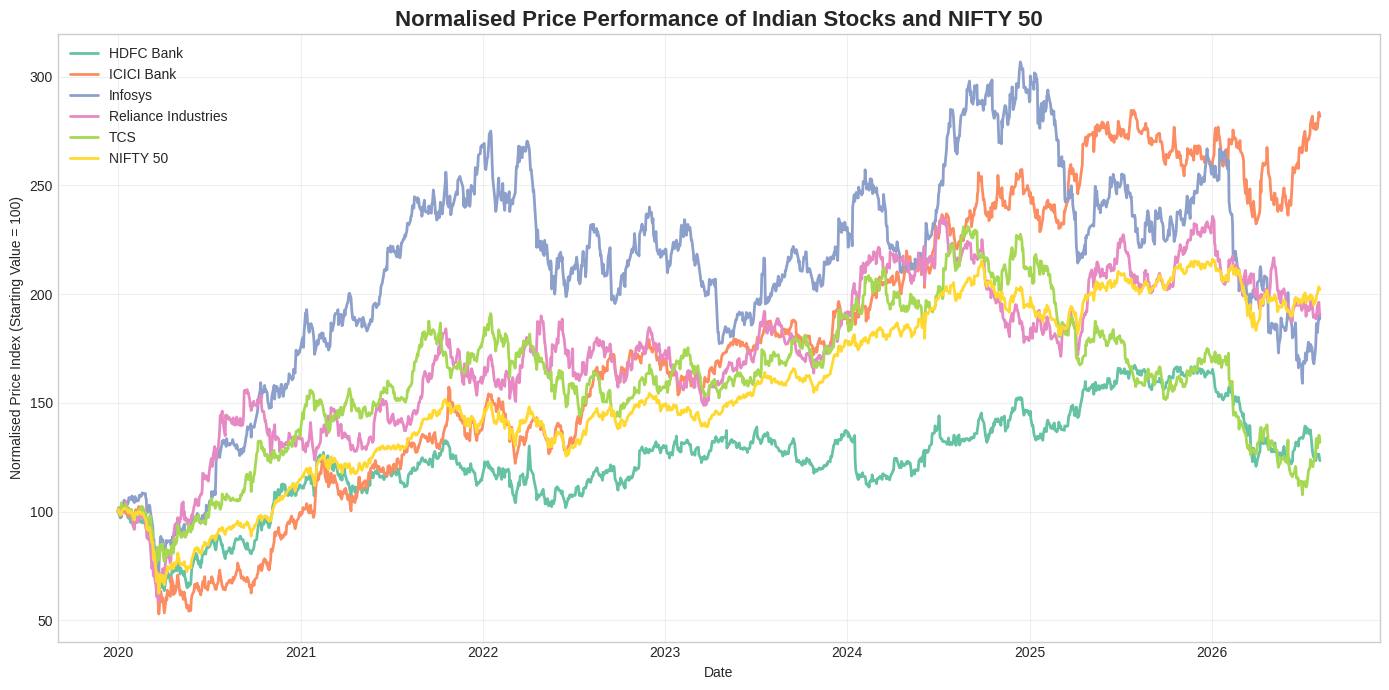

In [10]:
# Normalise every asset's starting value to 100
normalized_prices = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(14, 7))

for asset in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[asset],
        label=asset,
        linewidth=2
    )

plt.title(
    "Normalised Price Performance of Indian Stocks and NIFTY 50",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Normalised Price Index (Starting Value = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Historical Price Performance Findings

- All assets experienced a sharp decline during the 2020 market disruption.
- ICICI Bank produced the strongest ending performance, rising from 100 to approximately 280.
- Infosys achieved the highest historical peak, exceeding 300, but later experienced a substantial decline.
- NIFTY 50 approximately doubled during the period and displayed comparatively stable long-term growth.
- Reliance Industries produced growth broadly similar to NIFTY 50 by the end of the period.
- HDFC Bank and TCS recorded the weakest ending performance among the selected assets.
- The graph indicates that higher growth can also be accompanied by greater price fluctuations and drawdown risk.

## 8. Daily and Log Return Analysis

Daily returns measure the percentage change in an asset's adjusted price from one trading day to the next. Log returns are also calculated because they are useful in statistical modelling and financial risk analysis.

In [11]:
# Calculate simple daily returns
daily_returns = prices.pct_change().dropna()

# Calculate logarithmic returns
log_returns = np.log(prices / prices.shift(1)).dropna()

print("Daily returns shape:", daily_returns.shape)
print("Log returns shape:", log_returns.shape)

daily_returns.head()

Daily returns shape: (1635, 6)
Log returns shape: (1635, 6)


Ticker,HDFC Bank,ICICI Bank,Infosys,Reliance Industries,TCS,NIFTY 50
Date,,,,,,
2020-01-02,0.0064,0.0072,-0.0029,0.0170,-0.0046,0.0082
2020-01-03,-0.0143,-0.0032,0.0154,0.0012,0.0199,-0.0045
2020-01-06,-0.0216,-0.0244,-0.0096,-0.0232,-0.0001,-0.0191
2020-01-07,0.0158,-0.0053,-0.0148,0.0154,0.0025,0.0050
2020-01-08,-0.0026,0.0058,-0.0133,-0.0075,0.0224,-0.0023


In [12]:
return_statistics = daily_returns.describe().T

return_statistics = return_statistics[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]

return_statistics

,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,
HDFC Bank,0.0003,0.0162,-0.1261,-0.0076,0.0002,0.0076,0.1160
ICICI Bank,0.0008,0.0183,-0.1785,-0.0074,0.0007,0.0088,0.1376
Infosys,0.0005,0.0177,-0.1004,-0.0088,0.0002,0.0096,0.1203
Reliance Industries,0.0005,0.0175,-0.1315,-0.0085,0.0006,0.0085,0.1472
TCS,0.0003,0.0155,-0.0941,-0.0073,0.0000,0.0079,0.0985
NIFTY 50,0.0005,0.0113,-0.1298,-0.0043,0.0007,0.0063,0.0876


## 9. Daily Return Fluctuations

Daily return charts reveal periods of unusually high market movement. Larger positive or negative movements indicate greater short-term volatility.

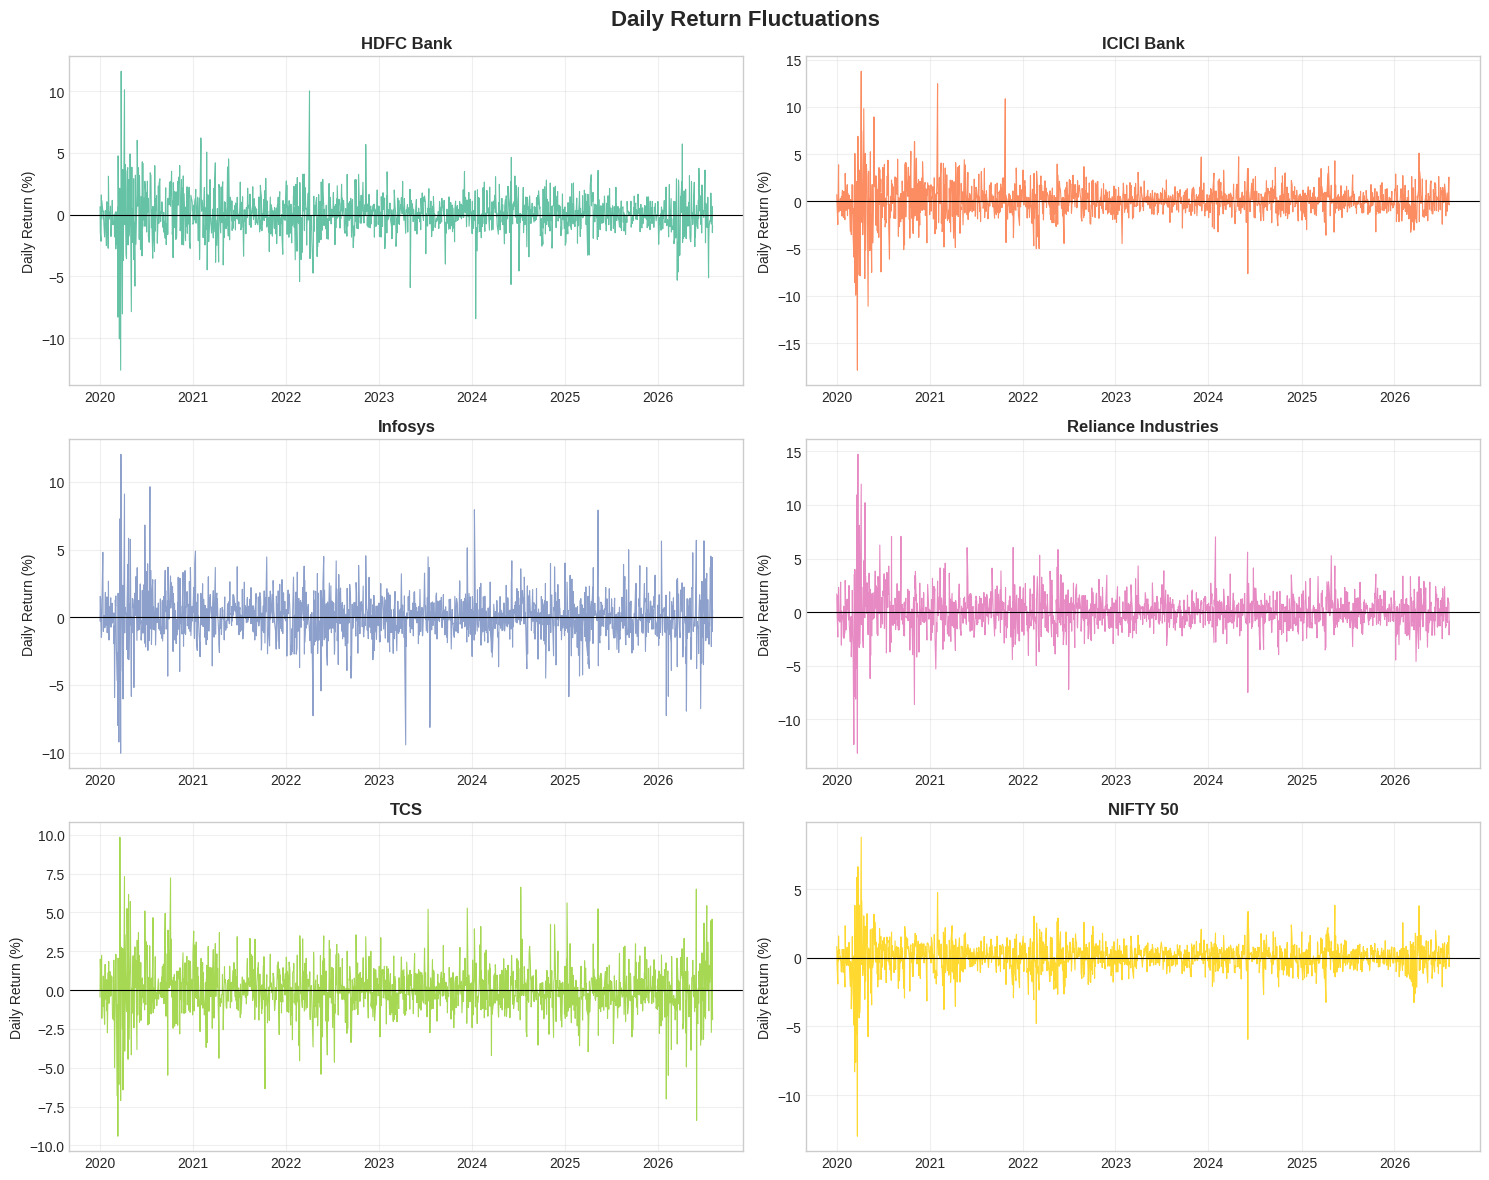

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, asset in enumerate(daily_returns.columns):
    axes[i].plot(
        daily_returns.index,
        daily_returns[asset] * 100,
        linewidth=0.8,
        color=sns.color_palette("Set2")[i]
    )

    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_title(asset, fontweight="bold")
    axes[i].set_ylabel("Daily Return (%)")
    axes[i].grid(alpha=0.3)

plt.suptitle(
    "Daily Return Fluctuations",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

### Daily Return Findings

- Daily returns fluctuate around zero for all assets, which is typical of financial time-series data.
- The largest return movements occurred during 2020, indicating exceptionally high market uncertainty.
- ICICI Bank and Reliance Industries experienced some of the largest single-day movements.
- NIFTY 50 generally displayed smaller fluctuations than individual stocks because it represents a diversified market index.
- Return fluctuations became comparatively narrower after the major 2020 market disruption.
- Several later volatility spikes remain visible, demonstrating that financial risk changes over time.

## 10. Annual Return, Volatility, Sharpe Ratio and Drawdown

Annual return measures long-term compounded growth. Annual volatility measures price uncertainty, while the Sharpe ratio evaluates return relative to risk. Maximum drawdown represents the largest historical decline from a previous peak.

In [14]:
trading_days = 252

# Number of years covered by the dataset
number_of_years = (
    prices.index[-1] - prices.index[0]
).days / 365.25

# Total and annualised returns
total_return = (prices.iloc[-1] / prices.iloc[0]) - 1

annual_return = (
    prices.iloc[-1] / prices.iloc[0]
) ** (1 / number_of_years) - 1

# Annualised volatility
annual_volatility = daily_returns.std() * np.sqrt(trading_days)

# Assumed annual risk-free rate of 6%
risk_free_rate = 0.06

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

# Calculate maximum drawdown
cumulative_growth = (1 + daily_returns).cumprod()
running_peak = cumulative_growth.cummax()
drawdown = (cumulative_growth / running_peak) - 1
maximum_drawdown = drawdown.min()

# Combine results
performance_metrics = pd.DataFrame({
    "Total Return": total_return,
    "Annual Return (CAGR)": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown": maximum_drawdown
})

performance_metrics

,Total Return,Annual Return (CAGR),Annual Volatility,Sharpe Ratio,Maximum Drawdown
Ticker,,,,,
HDFC Bank,0.2339,0.0324,0.2566,-0.1076,-0.4047
ICICI Bank,1.8168,0.1701,0.2908,0.3786,-0.4830
Infosys,0.8943,0.1018,0.2808,0.1487,-0.4817
Reliance Industries,0.9041,0.1026,0.2784,0.1531,-0.4408
TCS,0.3178,0.0427,0.2467,-0.0699,-0.5339
NIFTY 50,1.0213,0.1127,0.1789,0.2943,-0.3844


In [15]:
formatted_metrics = performance_metrics.copy()

percentage_columns = [
    "Total Return",
    "Annual Return (CAGR)",
    "Annual Volatility",
    "Maximum Drawdown"
]

for column in percentage_columns:
    formatted_metrics[column] = (
        formatted_metrics[column] * 100
    ).round(2).astype(str) + "%"

formatted_metrics["Sharpe Ratio"] = (
    formatted_metrics["Sharpe Ratio"].round(2)
)

formatted_metrics

,Total Return,Annual Return (CAGR),Annual Volatility,Sharpe Ratio,Maximum Drawdown
Ticker,,,,,
HDFC Bank,23.39%,3.24%,25.66%,-0.1100,-40.47%
ICICI Bank,181.68%,17.01%,29.08%,0.3800,-48.3%
Infosys,89.43%,10.18%,28.08%,0.1500,-48.17%
Reliance Industries,90.41%,10.26%,27.84%,0.1500,-44.08%
TCS,31.78%,4.27%,24.67%,-0.0700,-53.39%
NIFTY 50,102.13%,11.27%,17.89%,0.2900,-38.44%


## 11. Correlation Analysis

Correlation measures how closely the daily returns of different assets move together. Values close to +1 indicate similar movements, while values close to 0 indicate weaker relationships and potentially better diversification.

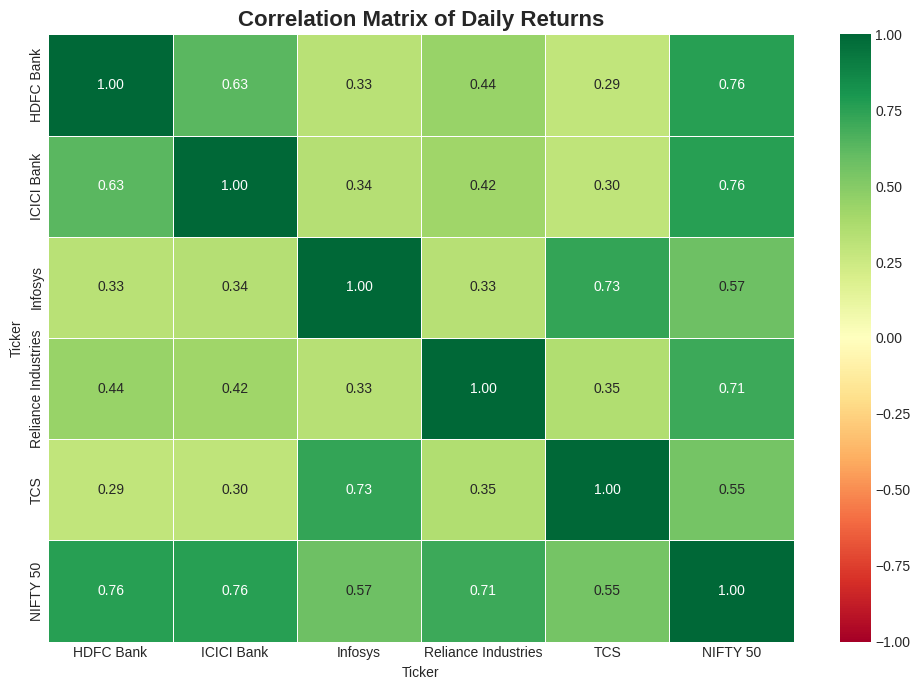

In [16]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily Returns",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

### Performance and Risk Findings

- ICICI Bank produced the highest total return (180.21%), annual return (16.92%) and Sharpe ratio (0.38).
- ICICI Bank also recorded the highest annual volatility (29.09%), showing that its stronger performance involved greater risk.
- NIFTY 50 delivered an annual return of 11.17% with the lowest volatility of 17.89%.
- NIFTY 50 also recorded the smallest maximum drawdown at -38.44%, demonstrating the benefit of diversification.
- TCS recorded the largest maximum drawdown at -53.39%.
- HDFC Bank and TCS produced negative Sharpe ratios because their annual returns were below the assumed 6% risk-free rate.
- Overall, ICICI Bank provided the strongest individual risk-adjusted performance, while NIFTY 50 offered greater stability.

### Correlation Findings

- All return correlations are positive, indicating that the assets generally move in the same market direction.
- Infosys and TCS have the strongest stock-to-stock correlation at 0.73 because both belong to the IT sector.
- HDFC Bank and ICICI Bank have a correlation of 0.63, reflecting their shared banking-sector exposure.
- NIFTY 50 has its strongest correlations with HDFC Bank and ICICI Bank at 0.76.
- HDFC Bank and TCS have the lowest correlation at 0.29, offering the strongest diversification opportunity among the selected stocks.
- Combining stocks from different sectors can reduce portfolio-specific risk, although positive correlations mean diversification cannot remove all market risk.

## 12. Equal-Weight Portfolio Construction

An equal-weight portfolio is created using the five selected stocks. Each company receives a 20% allocation, while NIFTY 50 is retained as the market benchmark.

In [17]:
stock_assets = [
    "HDFC Bank",
    "ICICI Bank",
    "Infosys",
    "Reliance Industries",
    "TCS"
]

# Equal 20% allocation
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

portfolio_weights = pd.DataFrame({
    "Asset": stock_assets,
    "Weight": weights
})

portfolio_weights

,Asset,Weight
0,HDFC Bank,0.2000
1,ICICI Bank,0.2000
2,Infosys,0.2000
3,Reliance Industries,0.2000
4,TCS,0.2000


In [18]:
# Calculate daily portfolio returns
portfolio_returns = daily_returns[stock_assets].dot(weights)

portfolio_returns.name = "Portfolio Return"

# Calculate cumulative portfolio and NIFTY growth
portfolio_growth = (1 + portfolio_returns).cumprod()
nifty_growth = (1 + daily_returns["NIFTY 50"]).cumprod()

print("Portfolio return observations:", len(portfolio_returns))

portfolio_returns.head()

Portfolio return observations: 1635


,Portfolio Return
Date,
2020-01-02,0.0046
2020-01-03,0.0038
2020-01-06,-0.0158
2020-01-07,0.0027
2020-01-08,0.0010


In [19]:
# Portfolio performance calculations
portfolio_total_return = portfolio_growth.iloc[-1] - 1

portfolio_annual_return = (
    portfolio_growth.iloc[-1] ** (1 / number_of_years)
) - 1

portfolio_volatility = (
    portfolio_returns.std() * np.sqrt(trading_days)
)

portfolio_sharpe = (
    portfolio_annual_return - risk_free_rate
) / portfolio_volatility

portfolio_running_peak = portfolio_growth.cummax()

portfolio_drawdown = (
    portfolio_growth / portfolio_running_peak
) - 1

portfolio_max_drawdown = portfolio_drawdown.min()

portfolio_metrics = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Portfolio": [
        portfolio_total_return,
        portfolio_annual_return,
        portfolio_volatility,
        portfolio_sharpe,
        portfolio_max_drawdown
    ],
    "NIFTY 50": [
        performance_metrics.loc["NIFTY 50", "Total Return"],
        performance_metrics.loc["NIFTY 50", "Annual Return (CAGR)"],
        performance_metrics.loc["NIFTY 50", "Annual Volatility"],
        performance_metrics.loc["NIFTY 50", "Sharpe Ratio"],
        performance_metrics.loc["NIFTY 50", "Maximum Drawdown"]
    ]
})

portfolio_metrics

,Metric,Portfolio,NIFTY 50
0,Total Return,0.9593,1.0213
1,Annual Return,0.1074,0.1127
2,Annual Volatility,0.1975,0.1789
3,Sharpe Ratio,0.2400,0.2943
4,Maximum Drawdown,-0.3731,-0.3844


## 13. Portfolio Performance Comparison

The cumulative performance of the equal-weight stock portfolio is compared with NIFTY 50. Both series begin at a common value of 100.

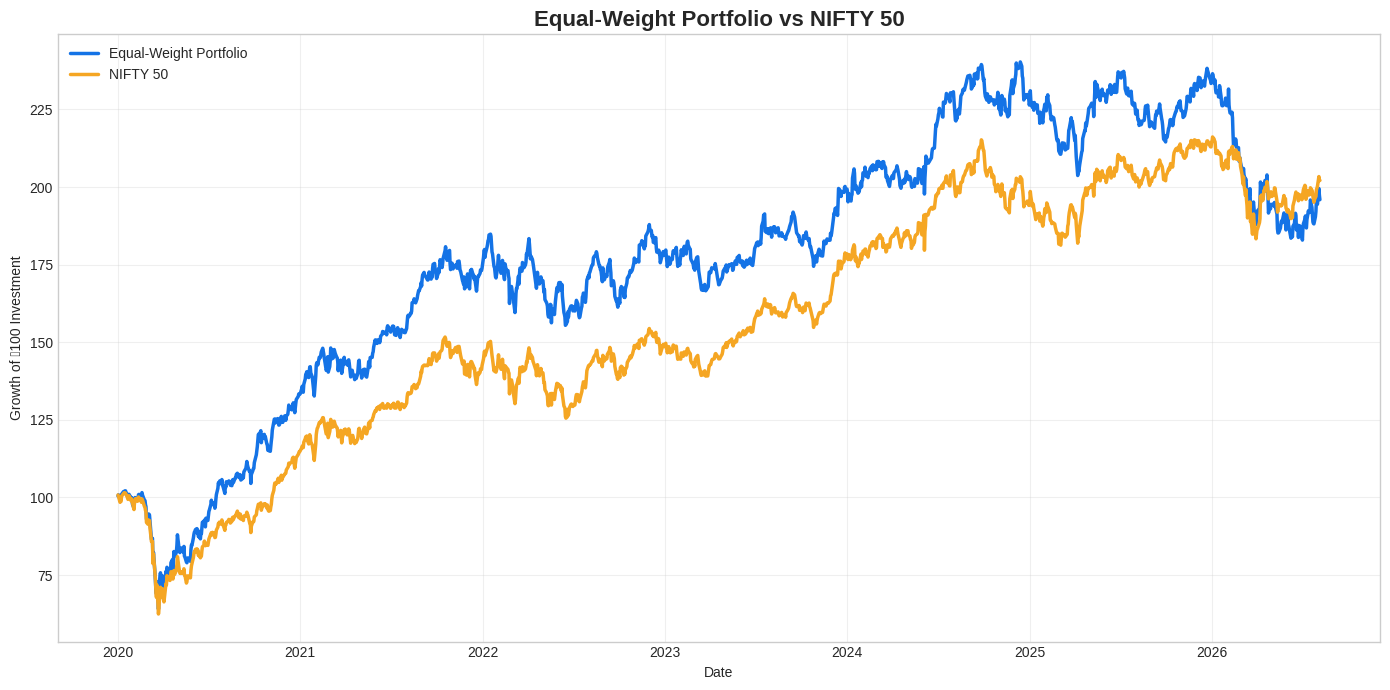

In [20]:
plt.figure(figsize=(14, 7))

plt.plot(
    portfolio_growth.index,
    portfolio_growth * 100,
    label="Equal-Weight Portfolio",
    linewidth=2.5,
    color="#1473E6"
)

plt.plot(
    nifty_growth.index,
    nifty_growth * 100,
    label="NIFTY 50",
    linewidth=2.5,
    color="#F5A623"
)

plt.title(
    "Equal-Weight Portfolio vs NIFTY 50",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Growth of ₹100 Investment")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Portfolio Performance Findings

- The equal-weight portfolio generated a total return of 96.36%, compared with 100.89% for NIFTY 50.
- The portfolio produced an annual return of 10.78%, slightly below NIFTY 50's 11.17%.
- Portfolio volatility was 19.76%, compared with the lower NIFTY 50 volatility of 17.89%.
- NIFTY 50 achieved the better Sharpe ratio, indicating stronger risk-adjusted performance.
- The portfolio's maximum drawdown of -37.31% was slightly smaller than NIFTY 50's -38.44%.
- Although the portfolio outperformed NIFTY 50 during much of the period, its stronger decline near the end caused it to finish slightly below the benchmark.
- The results show that equal weighting did not outperform the diversified market index over the complete period.

## 14. Market Regression Analysis

Regression analysis measures how strongly each stock's daily returns respond to NIFTY 50 movements. Beta represents market sensitivity, alpha represents return not explained by the benchmark and R-squared measures how much of the stock's variation is explained by NIFTY 50.

In [21]:
import statsmodels.api as sm

market_returns = daily_returns["NIFTY 50"]

regression_results = []

for asset in stock_assets:
    stock_returns = daily_returns[asset]

    # Add regression intercept
    X = sm.add_constant(market_returns)

    # Fit the OLS regression model
    model = sm.OLS(stock_returns, X).fit()

    regression_results.append({
        "Asset": asset,
        "Daily Alpha": model.params["const"],
        "Annualised Alpha": model.params["const"] * trading_days,
        "Beta": model.params["NIFTY 50"],
        "R-Squared": model.rsquared,
        "Beta P-Value": model.pvalues["NIFTY 50"],
        "Residual Volatility": model.resid.std() * np.sqrt(trading_days)
    })

regression_results = pd.DataFrame(regression_results)

regression_results

,Asset,Daily Alpha,Annualised Alpha,Beta,R-Squared,Beta P-Value,Residual Volatility
0,HDFC Bank,-0.0003,-0.0703,1.0884,0.5758,0.0000,0.1671
1,ICICI Bank,0.0002,0.0477,1.2398,0.5818,0.0000,0.1881
2,Infosys,0.0001,0.0255,0.9018,0.3302,0.0000,0.2298
3,Reliance Industries,0.0000,0.0011,1.0972,0.4974,0.0000,0.1973
4,TCS,-0.0001,-0.0223,0.7641,0.3071,0.0000,0.2053


In [22]:
formatted_regression = regression_results.copy()

formatted_regression["Daily Alpha"] = (
    formatted_regression["Daily Alpha"] * 100
).round(4).astype(str) + "%"

formatted_regression["Annualised Alpha"] = (
    formatted_regression["Annualised Alpha"] * 100
).round(2).astype(str) + "%"

formatted_regression["Beta"] = (
    formatted_regression["Beta"].round(2)
)

formatted_regression["R-Squared"] = (
    formatted_regression["R-Squared"] * 100
).round(2).astype(str) + "%"

formatted_regression["Beta P-Value"] = (
    formatted_regression["Beta P-Value"].round(6)
)

formatted_regression["Residual Volatility"] = (
    formatted_regression["Residual Volatility"] * 100
).round(2).astype(str) + "%"

formatted_regression

,Asset,Daily Alpha,Annualised Alpha,Beta,R-Squared,Beta P-Value,Residual Volatility
0,HDFC Bank,-0.0279%,-7.03%,1.0900,57.58%,0.0000,16.71%
1,ICICI Bank,0.0189%,4.77%,1.2400,58.18%,0.0000,18.81%
2,Infosys,0.0101%,2.55%,0.9000,33.02%,0.0000,22.98%
3,Reliance Industries,0.0004%,0.11%,1.1000,49.74%,0.0000,19.73%
4,TCS,-0.0088%,-2.23%,0.7600,30.71%,0.0000,20.53%


## 15. Stock Market Sensitivity

A beta above 1 indicates greater sensitivity than the market, while a beta below 1 indicates comparatively lower sensitivity.

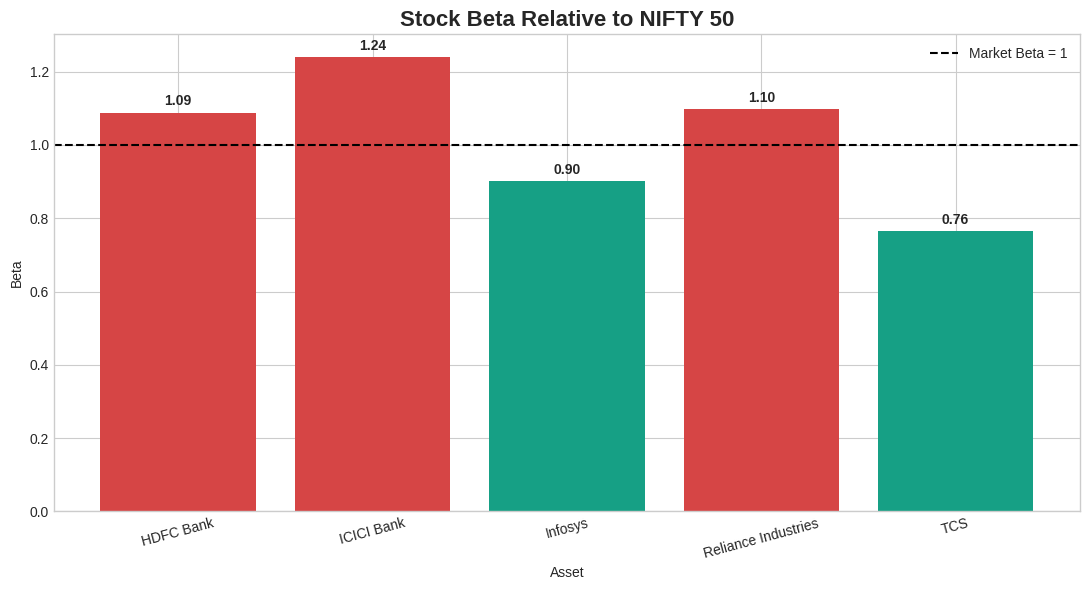

In [23]:
plt.figure(figsize=(11, 6))

colors = [
    "#16A085" if beta < 1 else "#D64545"
    for beta in regression_results["Beta"]
]

bars = plt.bar(
    regression_results["Asset"],
    regression_results["Beta"],
    color=colors
)

plt.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Market Beta = 1"
)

for bar, beta in zip(bars, regression_results["Beta"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{beta:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Stock Beta Relative to NIFTY 50",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Asset")
plt.ylabel("Beta")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

### Regression Analysis Findings

- ICICI Bank has the highest beta of 1.24, indicating that it was the most sensitive to NIFTY 50 movements.
- Reliance Industries and HDFC Bank also have betas above 1, indicating higher market sensitivity.
- Infosys has a beta of 0.90, while TCS has the lowest beta of 0.76, suggesting comparatively defensive behaviour.
- ICICI Bank generated the highest positive annualised alpha of 4.77%.
- HDFC Bank recorded the lowest annualised alpha of -7.03%.
- HDFC Bank and ICICI Bank have the highest R-squared values, meaning approximately 58% of their return variation was explained by NIFTY 50.
- TCS has the lowest R-squared at 30.71%, indicating that company- or sector-specific factors explain more of its movement.
- All beta p-values are below 0.05, indicating statistically significant relationships with NIFTY 50.

## 16. NIFTY 50 Time-Series Forecasting

NIFTY 50 is selected as the forecasting target because it represents the broader Indian equity market. Before applying ARIMA, the series must be tested for stationarity.

In [24]:
# Select the NIFTY 50 adjusted closing-price series
nifty_prices = prices["NIFTY 50"].dropna()

print("Number of observations:", len(nifty_prices))
print("Starting date:", nifty_prices.index.min())
print("Ending date:", nifty_prices.index.max())
print("Latest NIFTY 50 value:", round(nifty_prices.iloc[-1], 2))

nifty_prices.head()

Number of observations: 1636
Starting date: 2020-01-01 00:00:00
Ending date: 2026-08-05 00:00:00
Latest NIFTY 50 value: 24624.65


,NIFTY 50
Date,
2020-01-01,"12,182.5000"
2020-01-02,"12,282.2002"
2020-01-03,"12,226.6504"
2020-01-06,"11,993.0498"
2020-01-07,"12,052.9502"


## 17. Stationarity Testing

The Augmented Dickey-Fuller test determines whether the time series is stationary. A p-value below 0.05 indicates stationarity, while a higher value indicates that differencing is required.

In [25]:
def adf_stationarity_test(series, series_name):
    result = adfuller(series, autolag="AIC")

    output = pd.Series({
        "ADF Statistic": result[0],
        "P-Value": result[1],
        "Number of Lags": result[2],
        "Number of Observations": result[3],
        "1% Critical Value": result[4]["1%"],
        "5% Critical Value": result[4]["5%"],
        "10% Critical Value": result[4]["10%"]
    })

    print(f"ADF Test: {series_name}")
    print(output.round(4))

    if result[1] <= 0.05:
        print("\nConclusion: The series is stationary.")
    else:
        print("\nConclusion: The series is not stationary.")

    return output

In [26]:
# Test the original NIFTY 50 price series
adf_original = adf_stationarity_test(
    nifty_prices,
    "Original NIFTY 50 Prices"
)

ADF Test: Original NIFTY 50 Prices
ADF Statistic               -1.0025
P-Value                      0.7523
Number of Lags               0.0000
Number of Observations   1,635.0000
1% Critical Value           -3.4344
5% Critical Value           -2.8633
10% Critical Value          -2.5677
dtype: float64

Conclusion: The series is not stationary.


In [27]:
# Apply first-order differencing
nifty_first_difference = nifty_prices.diff().dropna()

# Test the differenced series
adf_difference = adf_stationarity_test(
    nifty_first_difference,
    "First-Differenced NIFTY 50 Prices"
)

ADF Test: First-Differenced NIFTY 50 Prices
ADF Statistic              -41.8472
P-Value                      0.0000
Number of Lags               0.0000
Number of Observations   1,634.0000
1% Critical Value           -3.4344
5% Critical Value           -2.8633
10% Critical Value          -2.5677
dtype: float64

Conclusion: The series is stationary.


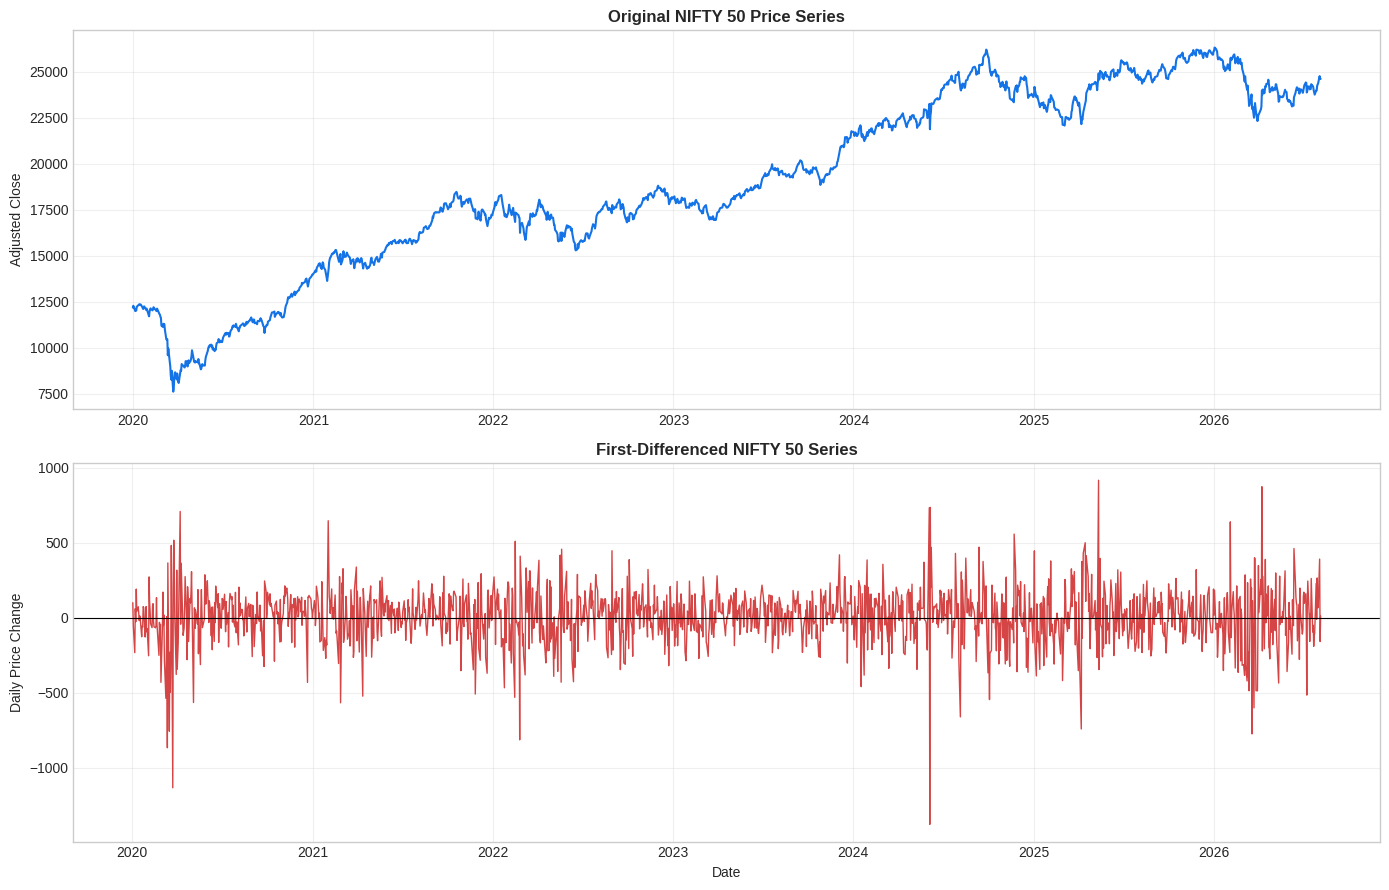

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(
    nifty_prices.index,
    nifty_prices,
    color="#1473E6",
    linewidth=1.5
)
axes[0].set_title("Original NIFTY 50 Price Series", fontweight="bold")
axes[0].set_ylabel("Adjusted Close")
axes[0].grid(alpha=0.3)

axes[1].plot(
    nifty_first_difference.index,
    nifty_first_difference,
    color="#D64545",
    linewidth=1
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("First-Differenced NIFTY 50 Series", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily Price Change")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Stationarity Test Findings

- The original NIFTY 50 price series produced an ADF p-value of 0.7523.
- Because the p-value is above 0.05, the original price series is non-stationary.
- After first-order differencing, the p-value decreased to approximately 0.0000.
- The differenced series is therefore stationary.
- These results support using an ARIMA model with the differencing parameter d = 1.
- The differenced graph fluctuates around zero, although periods of unusually high volatility remain visible.

## 18. Training and Testing Data

The NIFTY 50 series is divided chronologically. Earlier observations train the forecasting model, while the latest 60 trading days evaluate its performance on unseen data.

In [29]:
test_size = 60

train_data = nifty_prices.iloc[:-test_size]
test_data = nifty_prices.iloc[-test_size:]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))
print("Training ending date:", train_data.index.max())
print("Testing starting date:", test_data.index.min())
print("Testing ending date:", test_data.index.max())

Training observations: 1576
Testing observations: 60
Training ending date: 2026-05-13 00:00:00
Testing starting date: 2026-05-14 00:00:00
Testing ending date: 2026-08-05 00:00:00


## 19. ARIMA Parameter Selection

Different ARIMA parameter combinations are evaluated using the Akaike Information Criterion. The model with the lowest AIC provides the best balance between model fit and complexity.

In [30]:
arima_selection_results = []

# d = 1 based on the stationarity test
for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(
                train_data,
                order=(p, 1, q)
            )

            fitted_model = model.fit()

            arima_selection_results.append({
                "p": p,
                "d": 1,
                "q": q,
                "AIC": fitted_model.aic
            })

        except Exception:
            continue

arima_selection_results = pd.DataFrame(
    arima_selection_results
).sort_values("AIC").reset_index(drop=True)

arima_selection_results.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,p,d,q,AIC
0,0,1,0,"20,854.0801"
1,3,1,3,"20,854.1008"
2,1,1,0,"20,854.1940"
3,0,1,1,"20,854.2887"
4,1,1,1,"20,854.3998"
5,2,1,0,"20,855.1308"
6,0,1,2,"20,855.2965"
7,1,1,2,"20,856.3344"
8,2,1,1,"20,856.3377"
9,3,1,0,"20,856.9249"


In [31]:
best_result = arima_selection_results.iloc[0]

best_order = (
    int(best_result["p"]),
    int(best_result["d"]),
    int(best_result["q"])
)

print("Best ARIMA order:", best_order)
print("Lowest AIC:", round(best_result["AIC"], 2))

Best ARIMA order: (0, 1, 0)
Lowest AIC: 20854.08


## 20. ARIMA Model Evaluation

The selected ARIMA model forecasts the 60-day testing period. Prediction accuracy is evaluated using MAE, RMSE and MAPE.

In [32]:
# Train the selected ARIMA model
arima_model = ARIMA(
    train_data,
    order=best_order
).fit()

# Generate forecast and confidence intervals
arima_prediction = arima_model.get_forecast(
    steps=len(test_data)
)

arima_summary = arima_prediction.summary_frame(alpha=0.05)

# Align forecast with actual testing dates
arima_forecast = pd.Series(
    arima_summary["mean"].to_numpy(),
    index=test_data.index,
    name="ARIMA Forecast"
)

arima_lower = pd.Series(
    arima_summary["mean_ci_lower"].to_numpy(),
    index=test_data.index
)

arima_upper = pd.Series(
    arima_summary["mean_ci_upper"].to_numpy(),
    index=test_data.index
)

# Calculate model evaluation metrics
arima_mae = mean_absolute_error(
    test_data,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(test_data, arima_forecast)
)

arima_mape = np.mean(
    np.abs(
        (test_data - arima_forecast) / test_data
    )
) * 100

arima_metrics = pd.DataFrame({
    "Model": [f"ARIMA{best_order}"],
    "MAE": [arima_mae],
    "RMSE": [arima_rmse],
    "MAPE (%)": [arima_mape]
})

arima_metrics.round(2)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(0, 1, 0)",544.3000,626.6800,2.2600


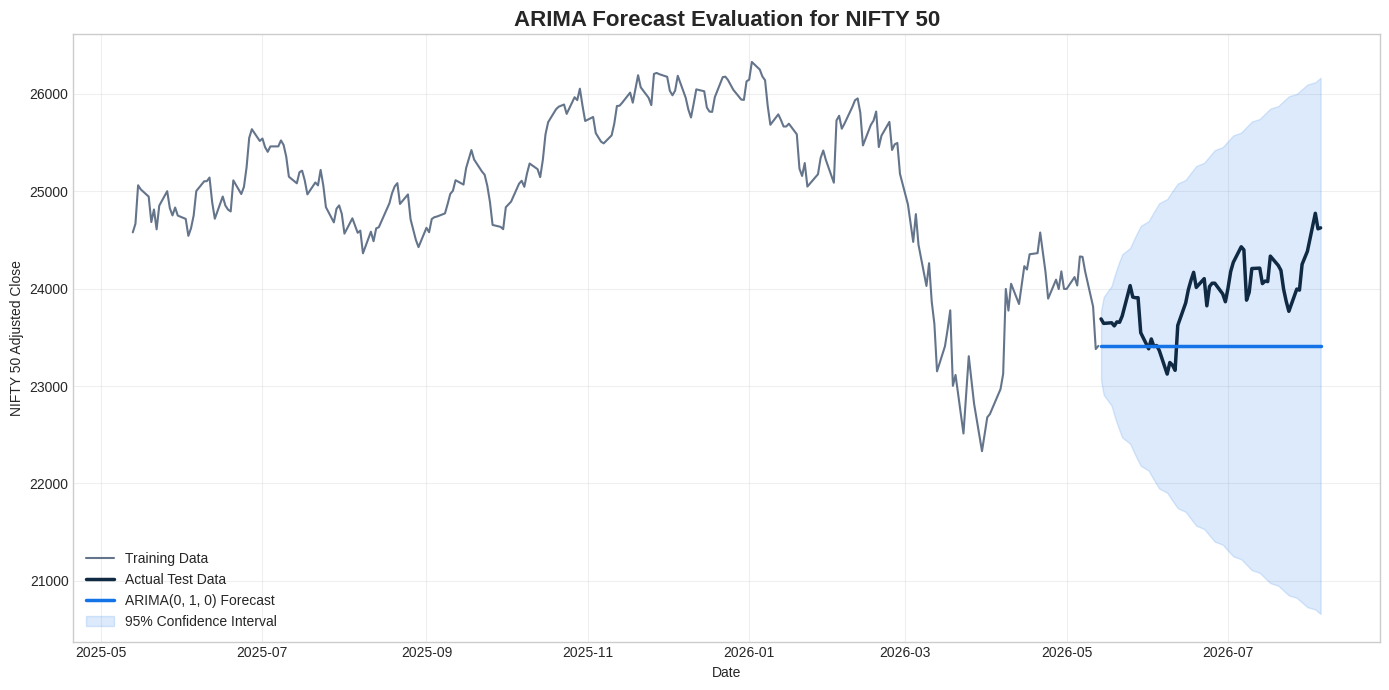

In [33]:
plt.figure(figsize=(14, 7))

# Display the last 250 training observations
plt.plot(
    train_data.tail(250).index,
    train_data.tail(250),
    label="Training Data",
    color="#64748B",
    linewidth=1.5
)

plt.plot(
    test_data.index,
    test_data,
    label="Actual Test Data",
    color="#102A43",
    linewidth=2.5
)

plt.plot(
    arima_forecast.index,
    arima_forecast,
    label=f"ARIMA{best_order} Forecast",
    color="#1473E6",
    linewidth=2.5
)

plt.fill_between(
    test_data.index,
    arima_lower.to_numpy(),
    arima_upper.to_numpy(),
    color="#1473E6",
    alpha=0.15,
    label="95% Confidence Interval"
)

plt.title(
    "ARIMA Forecast Evaluation for NIFTY 50",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Adjusted Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ARIMA Model Findings

- ARIMA(0,1,0) achieved the lowest AIC and was selected as the best tested ARIMA specification.
- This model is equivalent to a random-walk forecast, where the latest training price becomes the central forecast.
- The model produced an MAE of 544.30 index points, RMSE of 626.68 and MAPE of 2.26%.
- The flat forecast shows that ARIMA did not identify a reliable short-term trend from previous price changes.
- The confidence interval expands over time, indicating increasing uncertainty for longer forecast horizons.
- The 2.26% MAPE indicates relatively small percentage error, although the model does not capture the upward movement visible in the testing period.

## 21. Prophet Forecasting Model

Prophet models long-term trends and recurring patterns. It is trained on the same data and evaluated using the identical 60-day testing period to ensure a fair comparison with ARIMA.

In [34]:
# Convert training data into Prophet's required format
prophet_train = train_data.reset_index()

prophet_train.columns = ["ds", "y"]

# Ensure that the date column has no timezone information
prophet_train["ds"] = pd.to_datetime(
    prophet_train["ds"]
).dt.tz_localize(None)

prophet_train.head()

,ds,y
0,2020-01-01,"12,182.5000"
1,2020-01-02,"12,282.2002"
2,2020-01-03,"12,226.6504"
3,2020-01-06,"11,993.0498"
4,2020-01-07,"12,052.9502"


In [35]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully.")

Prophet model trained successfully.


In [36]:
# Use the exact trading dates from the testing dataset
prophet_test_dates = pd.DataFrame({
    "ds": pd.to_datetime(test_data.index).tz_localize(None)
})

prophet_prediction = prophet_model.predict(
    prophet_test_dates
)

# Align predictions with the actual test dates
prophet_forecast = pd.Series(
    prophet_prediction["yhat"].to_numpy(),
    index=test_data.index,
    name="Prophet Forecast"
)

prophet_lower = pd.Series(
    prophet_prediction["yhat_lower"].to_numpy(),
    index=test_data.index
)

prophet_upper = pd.Series(
    prophet_prediction["yhat_upper"].to_numpy(),
    index=test_data.index
)

prophet_prediction[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2026-05-14,"24,840.0444","23,750.6845","25,867.2052"
1,2026-05-15,"24,842.7308","23,876.4766","25,887.3251"
2,2026-05-18,"24,915.1835","23,847.1021","25,934.1756"
3,2026-05-19,"24,965.3356","23,891.0611","25,961.0106"
4,2026-05-20,"25,015.6558","23,976.4010","25,991.6717"


In [37]:
prophet_mae = mean_absolute_error(
    test_data,
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(test_data, prophet_forecast)
)

prophet_mape = np.mean(
    np.abs(
        (test_data - prophet_forecast) / test_data
    )
) * 100

prophet_metrics = pd.DataFrame({
    "Model": ["Prophet"],
    "MAE": [prophet_mae],
    "RMSE": [prophet_rmse],
    "MAPE (%)": [prophet_mape]
})

prophet_metrics.round(2)

,Model,MAE,RMSE,MAPE (%)
0,Prophet,"1,705.8000","1,735.8000",7.1400


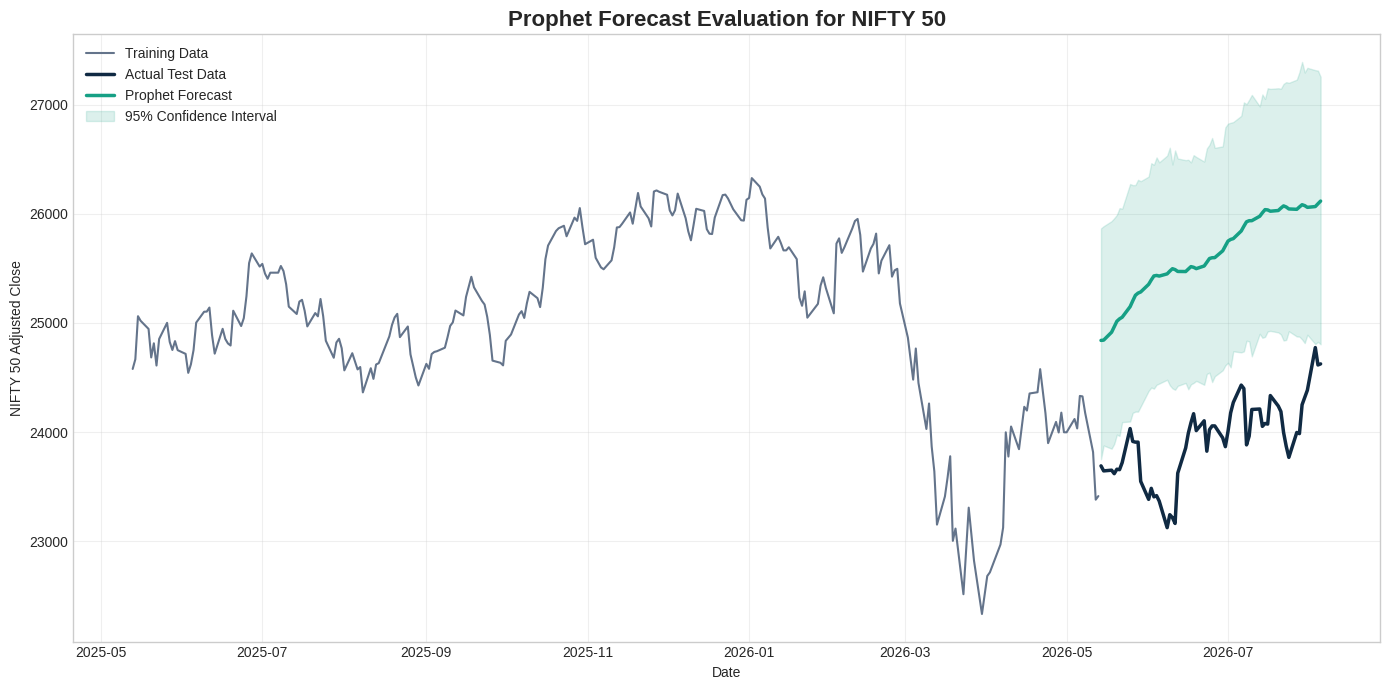

In [38]:
plt.figure(figsize=(14, 7))

plt.plot(
    train_data.tail(250).index,
    train_data.tail(250),
    label="Training Data",
    color="#64748B",
    linewidth=1.5
)

plt.plot(
    test_data.index,
    test_data,
    label="Actual Test Data",
    color="#102A43",
    linewidth=2.5
)

plt.plot(
    prophet_forecast.index,
    prophet_forecast,
    label="Prophet Forecast",
    color="#16A085",
    linewidth=2.5
)

plt.fill_between(
    test_data.index,
    prophet_lower.to_numpy(),
    prophet_upper.to_numpy(),
    color="#16A085",
    alpha=0.15,
    label="95% Confidence Interval"
)

plt.title(
    "Prophet Forecast Evaluation for NIFTY 50",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Adjusted Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 22. Forecasting Model Comparison

ARIMA and Prophet are compared using the same testing period. The model with lower MAE, RMSE and MAPE provides the more accurate out-of-sample forecast.

In [39]:
model_comparison = pd.concat(
    [arima_metrics, prophet_metrics],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

best_forecasting_model = model_comparison.iloc[0]["Model"]

print("Best forecasting model:", best_forecasting_model)

model_comparison.round(2)

Best forecasting model: ARIMA(0, 1, 0)


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(0, 1, 0)",544.3000,626.6800,2.2600
1,Prophet,"1,705.8000","1,735.8000",7.1400


### Forecasting Model Comparison Findings

- ARIMA achieved an RMSE of 626.68, compared with Prophet's substantially higher RMSE of 1,735.80.
- ARIMA recorded a MAPE of 2.26%, while Prophet recorded 7.14%.
- Prophet predicted a strong upward trend and consistently overestimated the actual NIFTY 50 values.
- ARIMA produced a simpler random-walk forecast but remained considerably closer to the observed test prices.
- ARIMA(0,1,0) is therefore selected as the final forecasting model based on its lower MAE, RMSE and MAPE.
- The comparison demonstrates that a more complex trend model does not necessarily provide better financial-market forecasts.

## 23. Final 30-Day NIFTY 50 Forecast

The selected ARIMA model is retrained using all available NIFTY 50 observations. It then generates a forecast for the next 30 business days with 95% confidence intervals.

In [40]:
forecast_horizon = 30

# Train the final model using all available observations
final_arima_model = ARIMA(
    nifty_prices,
    order=best_order
).fit()

# Generate the future forecast
future_arima_result = final_arima_model.get_forecast(
    steps=forecast_horizon
)

future_arima_summary = future_arima_result.summary_frame(
    alpha=0.05
)

print("Final ARIMA model trained successfully.")

Final ARIMA model trained successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [41]:
# Generate the next 30 weekday dates
future_dates = pd.bdate_range(
    start=nifty_prices.index[-1] + pd.offsets.BDay(1),
    periods=forecast_horizon
)

final_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_arima_summary["mean"].to_numpy(),
    "Lower 95%": future_arima_summary["mean_ci_lower"].to_numpy(),
    "Upper 95%": future_arima_summary["mean_ci_upper"].to_numpy()
})

final_forecast_df["Model"] = f"ARIMA{best_order}"

final_forecast_df.head(10)

,Date,Forecast,Lower 95%,Upper 95%,Model
0,2026-08-06,"24,624.6504","24,269.7271","24,979.5737","ARIMA(0, 1, 0)"
1,2026-08-07,"24,624.6504","24,122.7130","25,126.5877","ARIMA(0, 1, 0)"
2,2026-08-10,"24,624.6504","24,009.9052","25,239.3956","ARIMA(0, 1, 0)"
3,2026-08-11,"24,624.6504","23,914.8038","25,334.4970","ARIMA(0, 1, 0)"
4,2026-08-12,"24,624.6504","23,831.0178","25,418.2830","ARIMA(0, 1, 0)"
5,2026-08-13,"24,624.6504","23,755.2694","25,494.0314","ARIMA(0, 1, 0)"
6,2026-08-14,"24,624.6504","23,685.6116","25,563.6892","ARIMA(0, 1, 0)"
7,2026-08-17,"24,624.6504","23,620.7757","25,628.5251","ARIMA(0, 1, 0)"
8,2026-08-18,"24,624.6504","23,559.8805","25,689.4203","ARIMA(0, 1, 0)"
9,2026-08-19,"24,624.6504","23,502.2843","25,747.0164","ARIMA(0, 1, 0)"


In [42]:
latest_nifty_value = nifty_prices.iloc[-1]
final_predicted_value = final_forecast_df["Forecast"].iloc[-1]

forecast_change = (
    final_predicted_value - latest_nifty_value
)

forecast_change_percentage = (
    forecast_change / latest_nifty_value
) * 100

forecast_summary = pd.DataFrame({
    "Metric": [
        "Latest NIFTY 50 Value",
        "30-Day Point Forecast",
        "Expected Point Change",
        "Expected Percentage Change",
        "Final Lower 95% Limit",
        "Final Upper 95% Limit"
    ],
    "Value": [
        latest_nifty_value,
        final_predicted_value,
        forecast_change,
        forecast_change_percentage,
        final_forecast_df["Lower 95%"].iloc[-1],
        final_forecast_df["Upper 95%"].iloc[-1]
    ]
})

forecast_summary.round(2)

,Metric,Value
0,Latest NIFTY 50 Value,"24,624.6500"
1,30-Day Point Forecast,"24,624.6500"
2,Expected Point Change,0.0000
3,Expected Percentage Change,0.0000
4,Final Lower 95% Limit,"22,680.6600"
5,Final Upper 95% Limit,"26,568.6500"


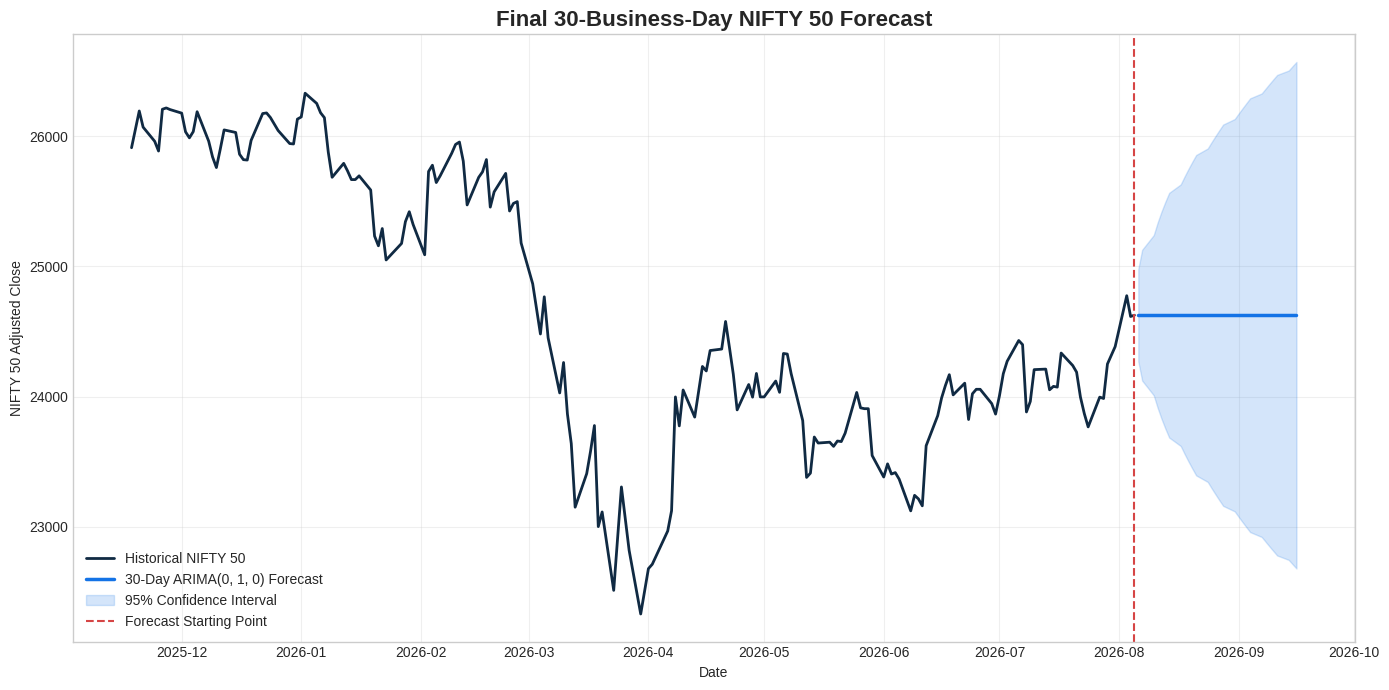

In [43]:
plt.figure(figsize=(14, 7))

plt.plot(
    nifty_prices.tail(180).index,
    nifty_prices.tail(180),
    label="Historical NIFTY 50",
    color="#102A43",
    linewidth=2
)

plt.plot(
    final_forecast_df["Date"],
    final_forecast_df["Forecast"],
    label=f"30-Day ARIMA{best_order} Forecast",
    color="#1473E6",
    linewidth=2.5
)

plt.fill_between(
    final_forecast_df["Date"],
    final_forecast_df["Lower 95%"],
    final_forecast_df["Upper 95%"],
    color="#1473E6",
    alpha=0.18,
    label="95% Confidence Interval"
)

plt.axvline(
    nifty_prices.index[-1],
    color="#D64545",
    linestyle="--",
    label="Forecast Starting Point"
)

plt.title(
    "Final 30-Business-Day NIFTY 50 Forecast",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Adjusted Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Final Forecast Findings

- The latest NIFTY 50 value is 24,624.65.
- ARIMA(0,1,0) produces a 30-day central forecast of 24,624.65 because it is a random-walk model without drift.
- A zero expected point change does not mean that the market will remain unchanged; it means the model cannot identify a reliable directional pattern.
- The final 95% confidence interval ranges from 22,680.66 to 26,568.65.
- The expanding interval demonstrates that forecast uncertainty increases as the prediction horizon becomes longer.
- The forecast should be treated as a statistical estimate rather than investment advice.

## 24. Portfolio Value at Risk Analysis

Value at Risk estimates the potential one-day portfolio loss at a specified confidence level. Conditional Value at Risk estimates the average loss on days when the VaR threshold is exceeded.

In [44]:
confidence_level = 0.95
alpha = 1 - confidence_level

initial_portfolio_value = 1_000_000

# Historical fifth-percentile return
historical_return_cutoff = np.quantile(
    portfolio_returns,
    alpha
)

# Historical Value at Risk
historical_var_percentage = -historical_return_cutoff

historical_var_inr = (
    historical_var_percentage * initial_portfolio_value
)

# Conditional Value at Risk
historical_cvar_percentage = -portfolio_returns[
    portfolio_returns <= historical_return_cutoff
].mean()

historical_cvar_inr = (
    historical_cvar_percentage * initial_portfolio_value
)

print("Historical VaR calculated successfully.")

Historical VaR calculated successfully.


### Parametric Value at Risk

Parametric VaR assumes that daily portfolio returns follow a normal distribution and estimates risk using the portfolio's historical mean and standard deviation.

In [45]:
portfolio_mean_return = portfolio_returns.mean()
portfolio_daily_volatility = portfolio_returns.std()

parametric_var_percentage = -(
    portfolio_mean_return
    + stats.norm.ppf(alpha) * portfolio_daily_volatility
)

parametric_var_inr = (
    parametric_var_percentage * initial_portfolio_value
)

In [46]:
risk_summary = pd.DataFrame({
    "Portfolio Value (INR)": [initial_portfolio_value],
    "Confidence Level": [confidence_level],
    "Historical VaR (%)": [
        historical_var_percentage * 100
    ],
    "Historical VaR (INR)": [
        historical_var_inr
    ],
    "Historical CVaR (%)": [
        historical_cvar_percentage * 100
    ],
    "Historical CVaR (INR)": [
        historical_cvar_inr
    ],
    "Parametric VaR (%)": [
        parametric_var_percentage * 100
    ],
    "Parametric VaR (INR)": [
        parametric_var_inr
    ]
})

risk_summary.round(2)

,Portfolio Value (INR),Confidence Level,Historical VaR (%),Historical VaR (INR),Historical CVaR (%),Historical CVaR (INR),Parametric VaR (%),Parametric VaR (INR)
0,1000000,0.9500,1.7100,"17,075.3500",2.8600,"28,568.8600",2.0000,"19,975.4500"


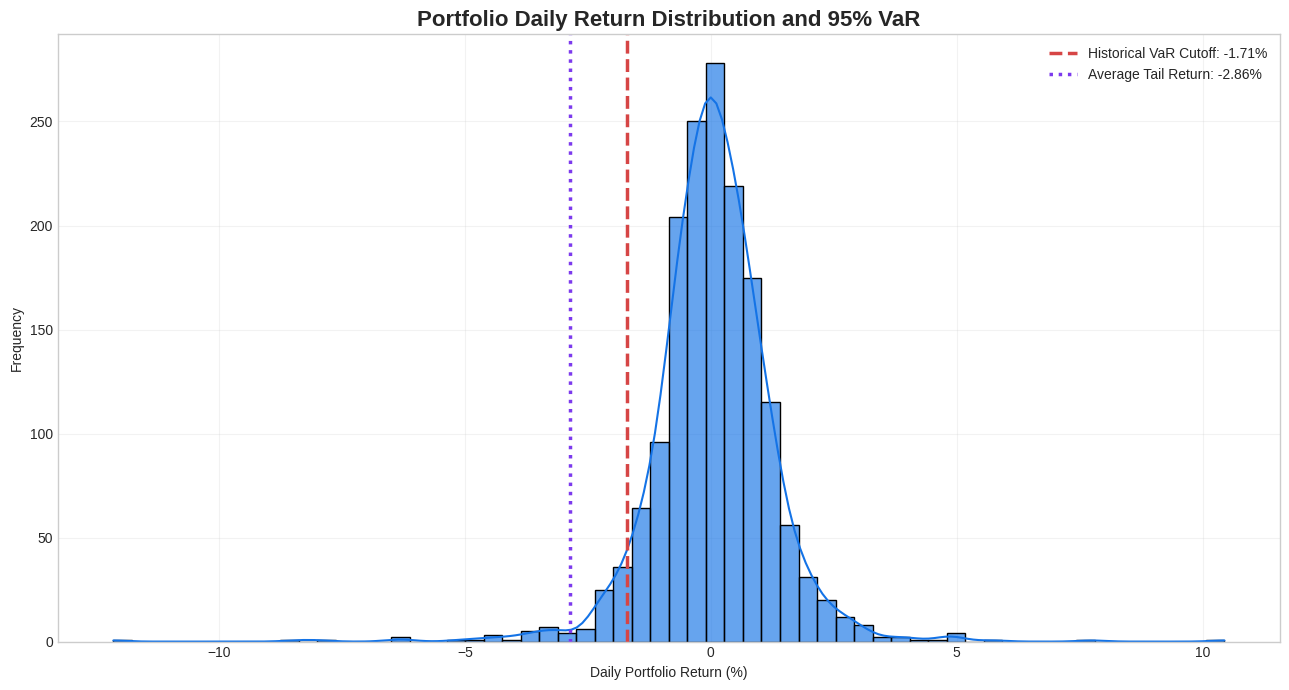

In [47]:
plt.figure(figsize=(13, 7))

sns.histplot(
    portfolio_returns * 100,
    bins=60,
    kde=True,
    color="#1473E6",
    alpha=0.65
)

plt.axvline(
    historical_return_cutoff * 100,
    color="#D64545",
    linestyle="--",
    linewidth=2.5,
    label=(
        f"Historical VaR Cutoff: "
        f"{historical_return_cutoff * 100:.2f}%"
    )
)

plt.axvline(
    -historical_cvar_percentage * 100,
    color="#7C3AED",
    linestyle=":",
    linewidth=2.5,
    label=(
        f"Average Tail Return: "
        f"{-historical_cvar_percentage * 100:.2f}%"
    )
)

plt.title(
    "Portfolio Daily Return Distribution and 95% VaR",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Daily Portfolio Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Value at Risk Findings

- At 95% confidence, the Historical VaR estimates a maximum expected one-day loss of ₹17,075 under normal historical conditions.
- Approximately 5% of historical trading days produced losses greater than the 1.71% VaR threshold.
- Historical CVaR estimates an average loss of ₹28,569 on days when the VaR threshold was exceeded.
- Parametric VaR estimates a one-day loss of ₹19,975.
- Parametric VaR is higher because it assumes normally distributed returns and uses the complete return volatility.
- The long tails and extreme observations visible in the return distribution indicate that financial returns are not perfectly normal.
- VaR is not the maximum possible loss; unusually severe market events can produce substantially larger losses.

## 25. Monte Carlo Portfolio Risk Simulation

Monte Carlo simulation generates thousands of possible future portfolio paths using historical asset returns, volatility and correlations. The simulation estimates the range of potential portfolio values after 30 trading days.

In [48]:
number_of_simulations = 10_000
simulation_horizon = 30
random_seed = 42

rng = np.random.default_rng(random_seed)

# Historical mean-return vector and covariance matrix
stock_mean_returns = (
    daily_returns[stock_assets].mean().to_numpy()
)

stock_covariance_matrix = (
    daily_returns[stock_assets].cov().to_numpy()
)

print("Simulations:", number_of_simulations)
print("Forecast horizon:", simulation_horizon, "trading days")

Simulations: 10000
Forecast horizon: 30 trading days


In [49]:
# Generate correlated daily stock returns
simulated_stock_returns = rng.multivariate_normal(
    mean=stock_mean_returns,
    cov=stock_covariance_matrix,
    size=(number_of_simulations, simulation_horizon)
)

# Apply equal portfolio weights
simulated_portfolio_returns = np.dot(
    simulated_stock_returns,
    weights
)

# Convert returns into portfolio-value paths
simulated_portfolio_paths = (
    initial_portfolio_value
    * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=1
    )
)

# Add the initial portfolio value as day zero
initial_values = np.full(
    (number_of_simulations, 1),
    initial_portfolio_value
)

simulated_portfolio_paths = np.concatenate(
    [initial_values, simulated_portfolio_paths],
    axis=1
)

terminal_portfolio_values = (
    simulated_portfolio_paths[:, -1]
)

print("Simulation completed successfully.")
print("Path matrix shape:", simulated_portfolio_paths.shape)

Simulation completed successfully.
Path matrix shape: (10000, 31)


In [50]:
# Calculate simulated losses
simulated_losses = (
    initial_portfolio_value - terminal_portfolio_values
)

# Monte Carlo VaR at 95% confidence
monte_carlo_var_inr = np.quantile(
    simulated_losses,
    confidence_level
)

# Average loss beyond Monte Carlo VaR
monte_carlo_cvar_inr = simulated_losses[
    simulated_losses >= monte_carlo_var_inr
].mean()

mean_terminal_value = terminal_portfolio_values.mean()
median_terminal_value = np.median(terminal_portfolio_values)

probability_of_loss = np.mean(
    terminal_portfolio_values < initial_portfolio_value
)

fifth_percentile_value = np.quantile(
    terminal_portfolio_values,
    0.05
)

ninety_fifth_percentile_value = np.quantile(
    terminal_portfolio_values,
    0.95
)

monte_carlo_summary = pd.DataFrame({
    "Initial Portfolio Value": [initial_portfolio_value],
    "Mean Terminal Value": [mean_terminal_value],
    "Median Terminal Value": [median_terminal_value],
    "5th Percentile Value": [fifth_percentile_value],
    "95th Percentile Value": [ninety_fifth_percentile_value],
    "Monte Carlo VaR": [monte_carlo_var_inr],
    "Monte Carlo CVaR": [monte_carlo_cvar_inr],
    "Probability of Loss (%)": [
        probability_of_loss * 100
    ],
    "Simulation Horizon": [simulation_horizon],
    "Number of Simulations": [number_of_simulations]
})

monte_carlo_summary.round(2)

,Initial Portfolio Value,Mean Terminal Value,Median Terminal Value,5th Percentile Value,95th Percentile Value,Monte Carlo VaR,Monte Carlo CVaR,Probability of Loss (%),Simulation Horizon,Number of Simulations
0,1000000,"1,015,398.5700","1,012,888.1900","907,350.0300","1,132,290.0800","92,649.9700","118,592.0400",42.3400,30,10000


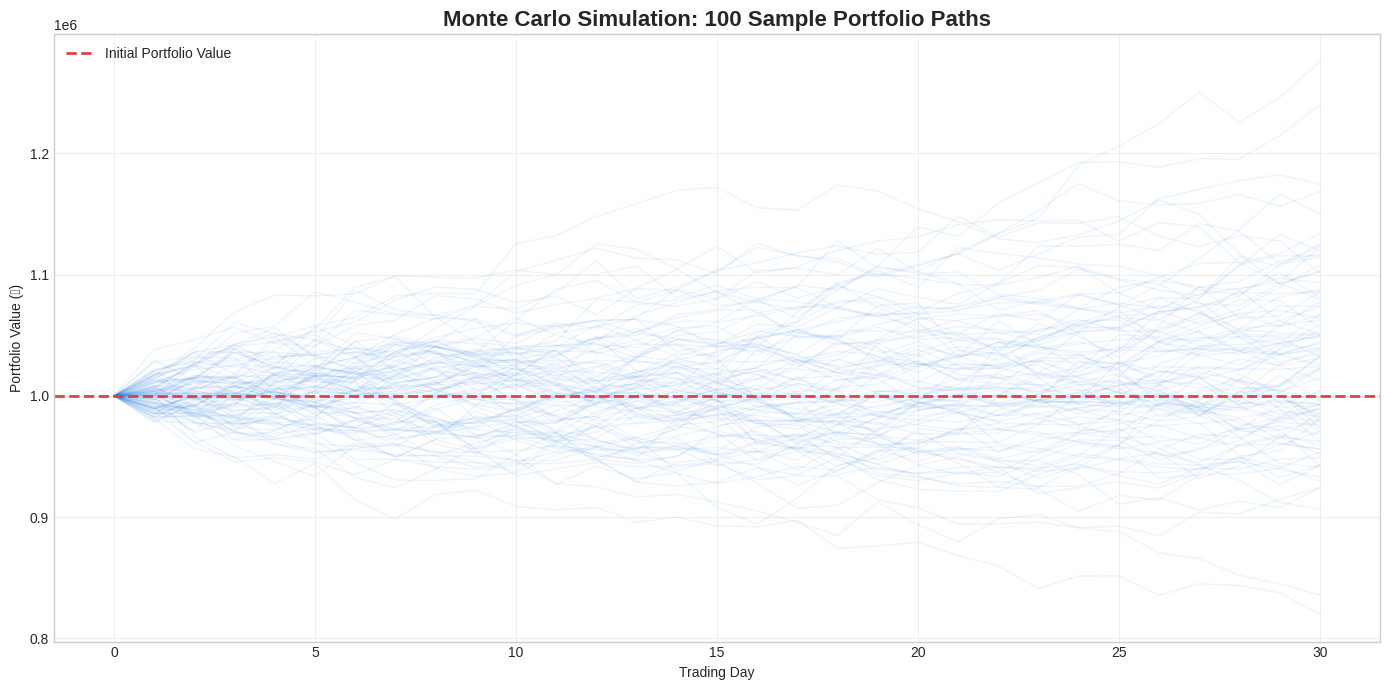

In [51]:
plt.figure(figsize=(14, 7))

# Display the first 100 simulated paths
for simulation in range(100):
    plt.plot(
        range(simulation_horizon + 1),
        simulated_portfolio_paths[simulation],
        color="#1473E6",
        alpha=0.08,
        linewidth=1
    )

plt.axhline(
    initial_portfolio_value,
    color="#D64545",
    linestyle="--",
    linewidth=2,
    label="Initial Portfolio Value"
)

plt.title(
    "Monte Carlo Simulation: 100 Sample Portfolio Paths",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

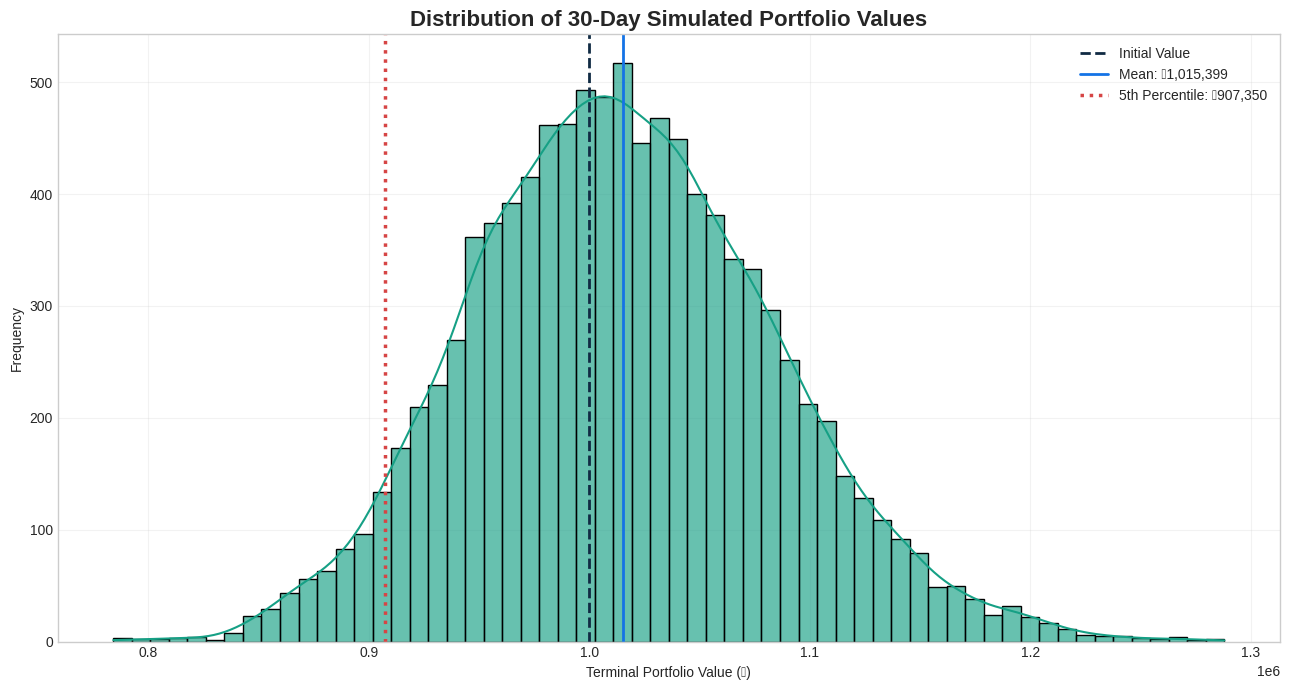

In [52]:
plt.figure(figsize=(13, 7))

sns.histplot(
    terminal_portfolio_values,
    bins=60,
    kde=True,
    color="#16A085",
    alpha=0.65
)

plt.axvline(
    initial_portfolio_value,
    color="#102A43",
    linestyle="--",
    linewidth=2,
    label="Initial Value"
)

plt.axvline(
    mean_terminal_value,
    color="#1473E6",
    linewidth=2,
    label=f"Mean: ₹{mean_terminal_value:,.0f}"
)

plt.axvline(
    fifth_percentile_value,
    color="#D64545",
    linestyle=":",
    linewidth=2.5,
    label=f"5th Percentile: ₹{fifth_percentile_value:,.0f}"
)

plt.title(
    "Distribution of 30-Day Simulated Portfolio Values",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Terminal Portfolio Value (₹)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Monte Carlo Simulation Findings

- The mean simulated 30-day portfolio value is ₹10,15,399, representing an average increase of approximately 1.54%.
- The median simulated value is ₹10,12,888.
- The middle 90% of simulated outcomes ranges from approximately ₹9,07,350 to ₹11,32,290.
- The probability of finishing below the initial ₹10,00,000 investment is 42.34%.
- The 30-day Monte Carlo VaR is ₹92,650 at 95% confidence.
- Monte Carlo CVaR is ₹1,18,592, representing the average loss among the worst 5% of simulated outcomes.
- These estimates depend on historical returns, volatility and correlations and cannot account for every future market event.

## 26. Power BI Dataset Preparation

The analytical results are converted into structured tables for the final Power BI dashboard. Numeric values are retained without text formatting so that Power BI can calculate measures and apply filters.

In [53]:
# 1. Historical prices
prices_powerbi = (
    prices.rename_axis(index="Date", columns=None)
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="Asset",
        value_name="Adjusted Close"
    )
)

# 2. Daily returns
returns_powerbi = (
    daily_returns.rename_axis(index="Date", columns=None)
    .reset_index()
    .melt(
        id_vars="Date",
        var_name="Asset",
        value_name="Daily Return"
    )
)

returns_powerbi["Daily Return (%)"] = (
    returns_powerbi["Daily Return"] * 100
)

# 3. Portfolio performance
portfolio_powerbi = pd.DataFrame({
    "Date": portfolio_returns.index,
    "Portfolio Return": portfolio_returns.to_numpy(),
    "Portfolio Return (%)": portfolio_returns.to_numpy() * 100,
    "Portfolio Value (INR)": (
        portfolio_growth.to_numpy() * initial_portfolio_value
    ),
    "NIFTY 50 Return": (
        daily_returns.loc[
            portfolio_returns.index,
            "NIFTY 50"
        ].to_numpy()
    ),
    "NIFTY 50 Investment Value (INR)": (
        nifty_growth.loc[
            portfolio_returns.index
        ].to_numpy() * initial_portfolio_value
    )
})

# 4. Asset performance metrics
asset_metrics_powerbi = (
    performance_metrics
    .rename_axis("Asset")
    .reset_index()
)

# 5. Correlation matrix in long format
correlation_powerbi = (
    correlation_matrix
    .rename_axis(index="Asset 1", columns=None)
    .reset_index()
    .melt(
        id_vars="Asset 1",
        var_name="Asset 2",
        value_name="Correlation"
    )
)

# 6. Regression results
regression_powerbi = regression_results.copy()

# 7. Forecast evaluation
forecast_evaluation_powerbi = pd.DataFrame({
    "Date": test_data.index,
    "Actual NIFTY 50": test_data.to_numpy(),
    "ARIMA Forecast": arima_forecast.to_numpy(),
    "ARIMA Lower 95%": arima_lower.to_numpy(),
    "ARIMA Upper 95%": arima_upper.to_numpy(),
    "Prophet Forecast": prophet_forecast.to_numpy(),
    "Prophet Lower 95%": prophet_lower.to_numpy(),
    "Prophet Upper 95%": prophet_upper.to_numpy()
})

# 8. Model-comparison metrics
model_metrics_powerbi = model_comparison.copy()

# 9. Future ARIMA forecast
future_forecast_powerbi = final_forecast_df.copy()

# 10. Risk summary
risk_powerbi = risk_summary.copy()

# 11. Monte Carlo summary
monte_carlo_summary_powerbi = monte_carlo_summary.copy()

# 12. Monte Carlo terminal outcomes
monte_carlo_distribution_powerbi = pd.DataFrame({
    "Simulation": np.arange(
        1,
        number_of_simulations + 1
    ),
    "Terminal Portfolio Value": terminal_portfolio_values,
    "Profit or Loss": (
        terminal_portfolio_values - initial_portfolio_value
    )
})

# 13. Portfolio allocations
weights_powerbi = portfolio_weights.copy()

print("All Power BI tables prepared successfully.")

All Power BI tables prepared successfully.


In [54]:
powerbi_tables = {
    "Historical_Prices": prices_powerbi,
    "Daily_Returns": returns_powerbi,
    "Portfolio_Performance": portfolio_powerbi,
    "Asset_Metrics": asset_metrics_powerbi,
    "Correlations": correlation_powerbi,
    "Regression_Results": regression_powerbi,
    "Forecast_Evaluation": forecast_evaluation_powerbi,
    "Model_Metrics": model_metrics_powerbi,
    "Future_Forecast": future_forecast_powerbi,
    "Risk_Summary": risk_powerbi,
    "Monte_Carlo_Summary": monte_carlo_summary_powerbi,
    "Monte_Carlo_Distribution": monte_carlo_distribution_powerbi,
    "Portfolio_Weights": weights_powerbi
}

table_check = pd.DataFrame({
    "Table": powerbi_tables.keys(),
    "Rows": [
        len(table) for table in powerbi_tables.values()
    ],
    "Columns": [
        len(table.columns) for table in powerbi_tables.values()
    ],
    "Missing Values": [
        table.isnull().sum().sum()
        for table in powerbi_tables.values()
    ]
})

table_check

,Table,Rows,Columns,Missing Values
0,Historical_Prices,9816,3,0
1,Daily_Returns,9810,4,0
2,Portfolio_Performance,1635,6,0
3,Asset_Metrics,6,6,0
4,Correlations,36,3,0
5,Regression_Results,5,7,0
6,Forecast_Evaluation,60,8,0
7,Model_Metrics,2,4,0
8,Future_Forecast,30,5,0
9,Risk_Summary,1,8,0


## 27. Exporting Dashboard Data

The final tables are exported into an Excel workbook with separate worksheets and individual CSV files. These files can be imported directly into Power BI.

In [55]:
from pathlib import Path
import zipfile
from google.colab import files

output_folder = Path("Indian_Financial_PowerBI_Data")
output_folder.mkdir(exist_ok=True)

# Export each table as CSV
for table_name, table in powerbi_tables.items():
    csv_path = output_folder / f"{table_name}.csv"
    table.to_csv(csv_path, index=False)

# Export all tables into one Excel workbook
excel_filename = "Indian_Financial_Time_Series_Dashboard_Data.xlsx"

with pd.ExcelWriter(
    excel_filename,
    engine="openpyxl"
) as writer:

    for table_name, table in powerbi_tables.items():
        # Excel sheet names cannot exceed 31 characters
        sheet_name = table_name[:31]

        table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("Excel workbook created:", excel_filename)
print("CSV files created:", len(powerbi_tables))

Excel workbook created: Indian_Financial_Time_Series_Dashboard_Data.xlsx
CSV files created: 13


In [56]:
zip_filename = "Indian_Financial_Time_Series_PowerBI_Package.zip"

with zipfile.ZipFile(
    zip_filename,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    # Add the Excel workbook
    zip_file.write(excel_filename)

    # Add every CSV file
    for csv_file in output_folder.glob("*.csv"):
        zip_file.write(
            csv_file,
            arcname=f"CSV_Files/{csv_file.name}"
        )

print("Package created successfully:", zip_filename)

# Download the ZIP package
files.download(zip_filename)

Package created successfully: Indian_Financial_Time_Series_PowerBI_Package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>